**Author:** Dr. Alexis Hucteau  
**Contact:** [LinkedIn](https://www.linkedin.com/in/alexis-hucteau/) [Malt](https://www.malt.fr/profile/alexishucteau1)  
**Date:** May 2026

### Licensing Notice
- **Code:** This work is licensed under the [GNU GPL v3](https://www.gnu.org/licenses/gpl-3.0.html).
- **Analysis & Visualizations:** The interpretive content of this notebook is licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).

*Copyright (c) 2026 Alexis Hucteau. All rights reserved.*

In [17]:
import pandas as pd
import numpy as np

premier_tour = pd.read_parquet('../data/processed/premier_tour_cleaned.parquet')
deuxieme_tour = pd.read_parquet('../data/processed/deuxieme_tour_cleaned.parquet')

# Analyse du premier tour

In [18]:
display(premier_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Briançon,...,Meilhac,Piquemal,Pedinotti,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,1,0005,957,401,556,556,4,2,550,121,...,9,208,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
1,1,0007,892,384,508,508,2,1,505,98,...,2,134,7,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00V\xf3m\r\xae\x1a\xf7?\xf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.417,Bureau de vote : 007\nLieu de vote : Salle Bar...,417,Salle Barcelone
2,1,0014,1159,513,646,646,3,3,640,165,...,6,245,6,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xe9P\xc9\xe7\xac:\xf7?L...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.516,Bureau de vote : 014\nLieu de vote : École élé...,516,École élémentaire Bayard
3,1,0017,1131,362,769,769,3,1,765,223,...,10,229,10,60 rue Matabiau,b'\x01\x01\x00\x00\x00\xd8)\xe8G\xf8&\xf7?\xb8...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.486,Bureau de vote : 017\nLieu de vote : École élé...,486,École élémentaire Bayard
4,1,0018,781,328,453,453,4,2,447,126,...,8,122,4,6 rue du Lieutenant Colonnel Pélissier,b'\x01\x01\x00\x00\x00\xff\xf2^\xebH:\xf7?\xcf...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.463,Bureau de vote : 018\nLieu de vote : Salle Osè...,463,Salle Osète


In [19]:
emargement = premier_tour['votants'] == premier_tour['votants_ap_emargement']

emargement.value_counts()

display(premier_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])


,bureau,votants,votants_ap_emargement
7,0029,730,731
13,0060,669,668
62,0022,620,621
63,0023,636,635
70,0048,791,790
74,0079,701,697
93,0167,553,552
96,0209,603,604
97,0210,677,676
106,0240,428,429


Text(0.5, 1.0, 'Taux de participation au premier Tour à travers les différents bureaux de vote')

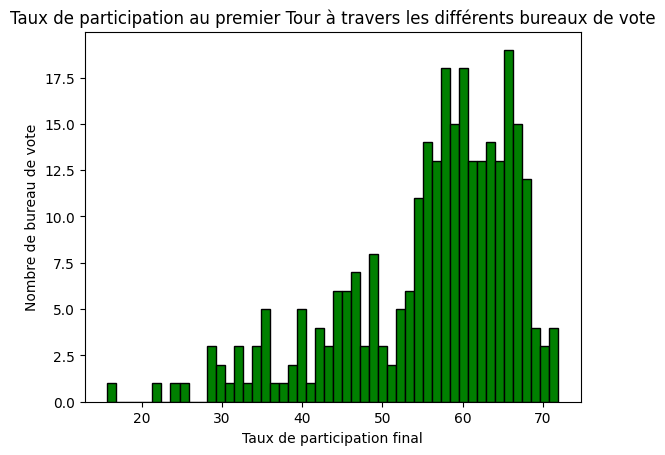

In [20]:
import matplotlib.pyplot as plt

premier_tour['tx_participation'] = (premier_tour['votants'] / premier_tour['inscrits'])*100
n, bins, patches = plt.hist(premier_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au premier Tour à travers les différents bureaux de vote')

Text(0.5, 1.0, 'Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

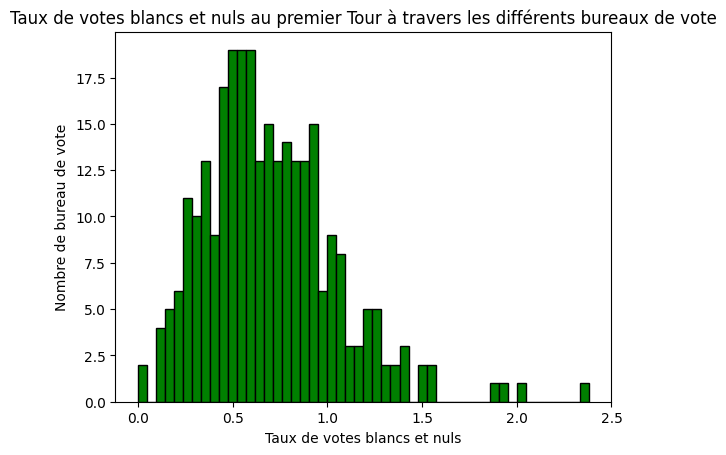

In [21]:
premier_tour['tx_nuls_blc'] = ((premier_tour['blancs'] + premier_tour['nuls']) / premier_tour['inscrits'])*100
n, bins, patches = plt.hist(premier_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au premier Tour à travers les différents bureaux de vote')

In [44]:
scores_vivre_mieux = (premier_tour['Briançon'] / premier_tour['votants']) *100
scores_NPA = (premier_tour['Scalli'] / premier_tour['votants']) *100
scores_Lutte = (premier_tour['Adrada'] / premier_tour['votants']) *100
scores_TRAVAILLEURS  = (premier_tour['Menendez'] / premier_tour['votants']) *100
scores_RN = (premier_tour['Leonardelli'] / premier_tour['votants']) *100
scores_RECONQUETE  = (premier_tour['Cottrel'] / premier_tour['votants']) *100
scores_NOUVEL_AIR = (premier_tour['Meilhac'] / premier_tour['votants']) *100
scores_RV = (premier_tour['Pedinotti'] / premier_tour['votants']) *100
scores_Moudenc = (premier_tour['Moudenc'] / premier_tour['votants']) *100
scores_Piquemal = (premier_tour['Piquemal'] / premier_tour['votants']) *100

scores_gauche = scores_vivre_mieux + scores_Piquemal + scores_RV + scores_TRAVAILLEURS + scores_Lutte + scores_NPA
scores_union_deuxieme_tour = scores_vivre_mieux + scores_Piquemal
scores_droite = scores_Moudenc + scores_RN + scores_RECONQUETE
scores_premier_tour = {'scores_vivre_mieux' : scores_vivre_mieux, 
                       'scores_RN' : scores_RN,
                        'scores_Moudenc' : scores_Moudenc, 'scores_Piquemal' : scores_Piquemal, 
                        'scores_gauche' : scores_gauche, 'scores_droite' : scores_droite, 'scores_union_deuxieme_tour' : scores_union_deuxieme_tour
}

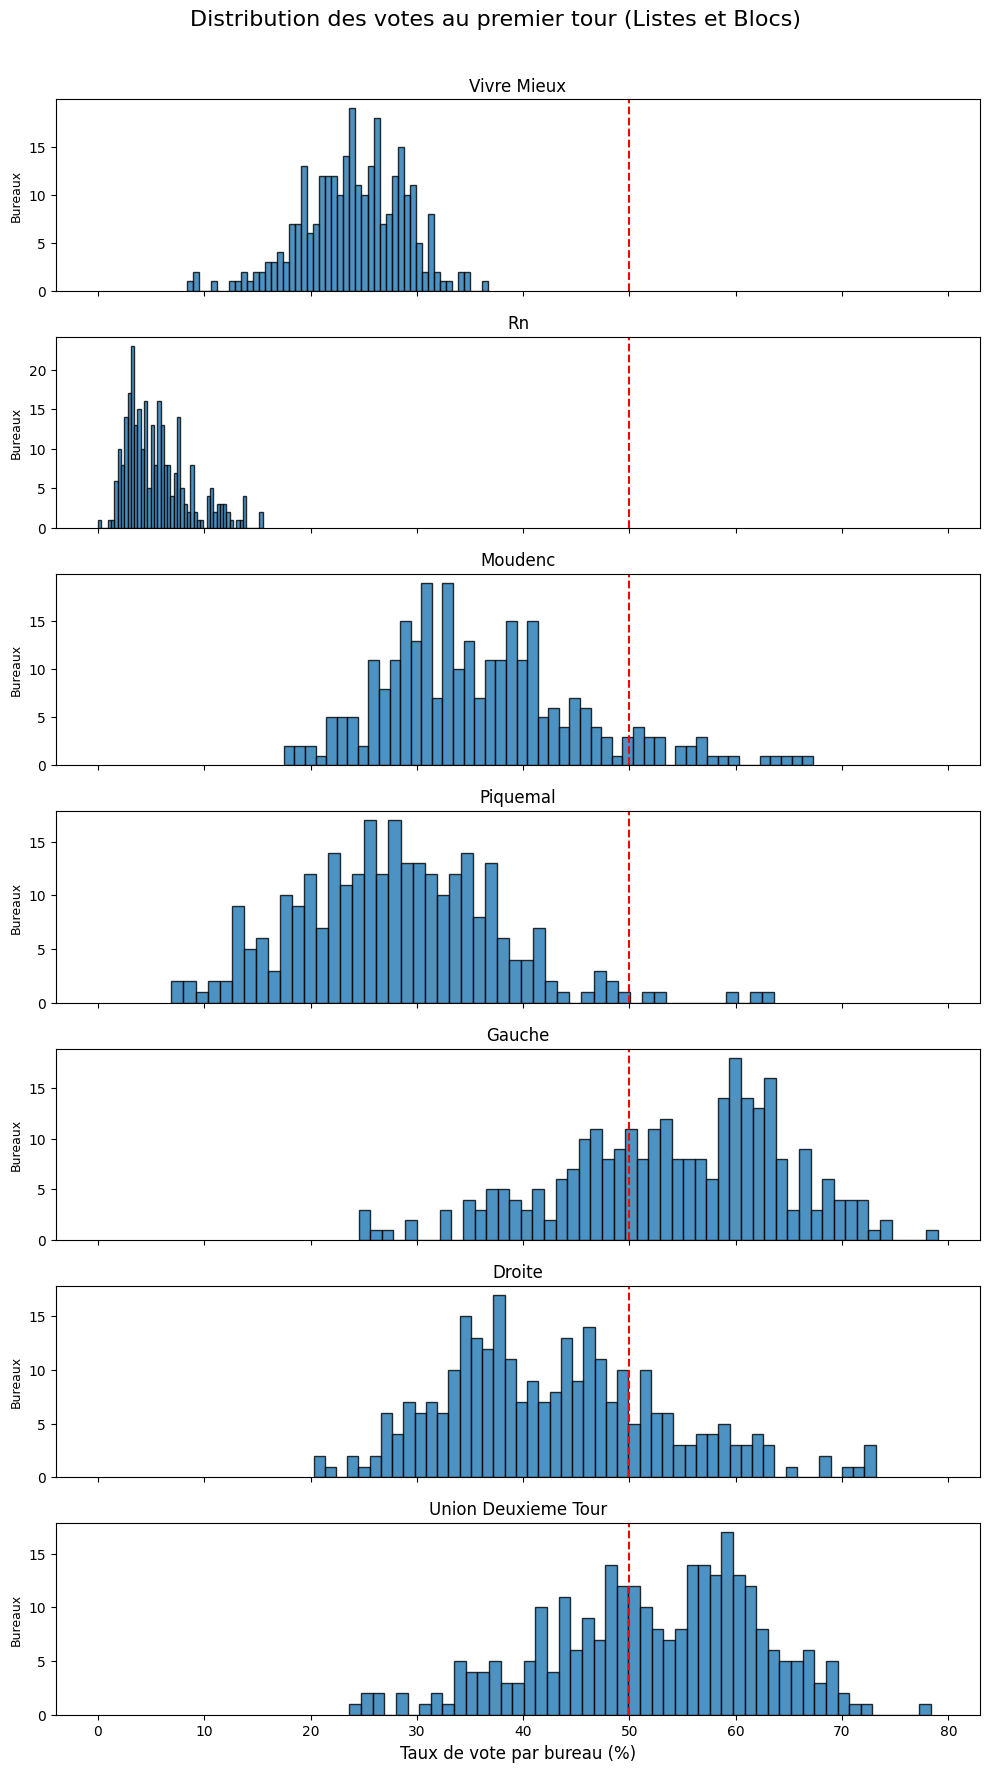

In [45]:
n_graphs = len(scores_premier_tour)

fig, axes = plt.subplots(nrows=n_graphs, ncols=1, figsize=(10, 2.5 * n_graphs), sharex=True)

for ax, (nom_variable, donnees) in zip(axes, scores_premier_tour.items()):
    
    ax.hist(donnees, bins=50, edgecolor='black', alpha=0.8)
    
    titre_propre = nom_variable.replace('scores_', '').replace('_', ' ').title()
    ax.set_title(titre_propre, fontsize=12)
    ax.set_ylabel('Bureaux', fontsize=9)
    
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50%')

axes[-1].set_xlabel('Taux de vote par bureau (%)', fontsize=12)

fig.suptitle('Distribution des votes au premier tour (Listes et Blocs)', fontsize=16, y=1.01)

plt.tight_layout()

plt.show()

# Analyse du Second tour

In [24]:
display(deuxieme_tour.head())

,Tour,bureau,inscrits,abstentions,votants,votants_ap_emargement,blancs,nuls,exprimes,Moudenc,Piquemal,adresse,Geo_Point,Geo_Shape,gml_id,infobulle,oid,Nom
0,2,0002,901,264,637,637,10,3,624,345,279,Place du Capitole,b'\x01\x01\x00\x00\x00\x87Z\xa4&\xee\x16\xf7?*...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.321,Bureau de vote : 002\nLieu de vote : Capitole ...,321,Capitole – Salle des Commissions
1,2,0005,956,335,621,621,15,4,602,292,310,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00<\xa5\x9c\x8e\x81\xff\xf...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.385,Bureau de vote : 005\nLieu de vote : Salle Bar...,385,Salle Barcelone
2,2,0006,925,325,600,600,11,3,586,274,312,22 Allée de Barcelone,b'\x01\x01\x00\x00\x00H\x8e#C\x1e\x0f\xf7?\xbe...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.510,Bureau de vote : 006\nLieu de vote : Salle Bar...,510,Salle Barcelone
3,2,0010,1107,334,773,773,14,6,753,403,350,13 boulevard d'Arcole,b'\x01\x01\x00\x00\x00\xa6\x03\xd8\xad\\\x06\x...,b'\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...,_94d1e486-db2d-11f0-aba6-35e62459877d.430,Bureau de vote : 010\nLieu de vote : École élé...,430,École élémentaire du Nord
4,2,0013,1157,401,756,756,10,6,740,346,394,60 rue Matabiau,b'\x01\x01\x00\x00\x00\x90j\x80\x02\xc7.\xf7?8...,"b""\x01\x06\x00\x00\x00\x01\x00\x00\x00\x01\x03...",_94d1e486-db2d-11f0-aba6-35e62459877d.557,Bureau de vote : 013\nLieu de vote : École élé...,557,École élémentaire Bayard


In [25]:
emargement = deuxieme_tour['votants'] == deuxieme_tour['votants_ap_emargement']

emargement.value_counts()

display(deuxieme_tour.loc[~emargement, ['bureau', 'votants', 'votants_ap_emargement']])

,bureau,votants,votants_ap_emargement
18,0057,673,672
20,0060,766,767
46,0204,382,381
53,0238,661,657
54,0239,599,598
63,0001,686,687
64,0003,538,537
77,0053,775,776
94,0136,621,622
95,0138,762,761


Text(0.5, 1.0, 'Taux de participation au deuxième Tour à travers les différents bureaux de vote')

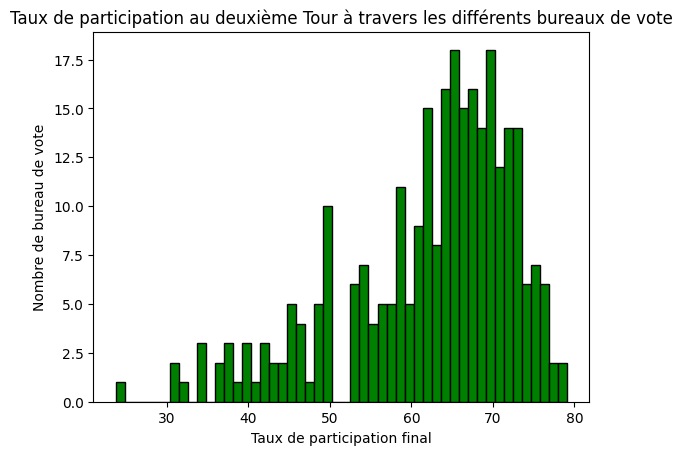

In [12]:
deuxieme_tour['tx_participation'] = (deuxieme_tour['votants'] / deuxieme_tour['inscrits'])*100
n, bins, patches = plt.hist(deuxieme_tour['tx_participation'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de participation final')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de participation au deuxième Tour à travers les différents bureaux de vote')

Text(0.5, 1.0, 'Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

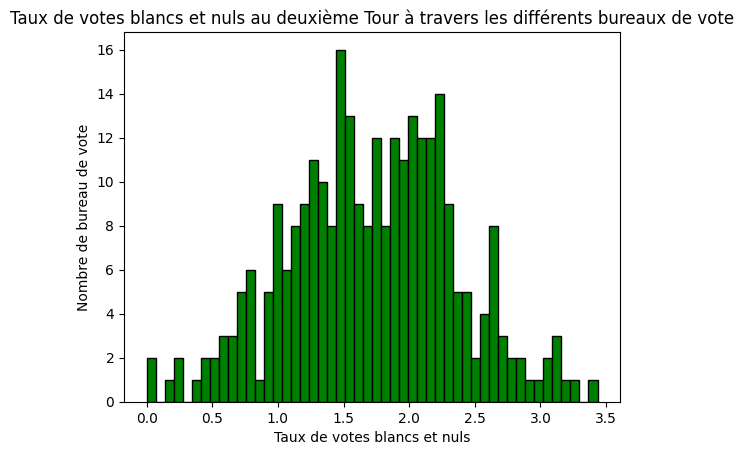

In [16]:
deuxieme_tour['tx_nuls_blc'] = ((deuxieme_tour['blancs'] + deuxieme_tour['nuls']) / deuxieme_tour['inscrits'])*100
n, bins, patches = plt.hist(deuxieme_tour['tx_nuls_blc'], 50, edgecolor = 'black', facecolor = 'green')
plt.xlabel('Taux de votes blancs et nuls')
plt.ylabel('Nombre de bureau de vote')
plt.title('Taux de votes blancs et nuls au deuxième Tour à travers les différents bureaux de vote')

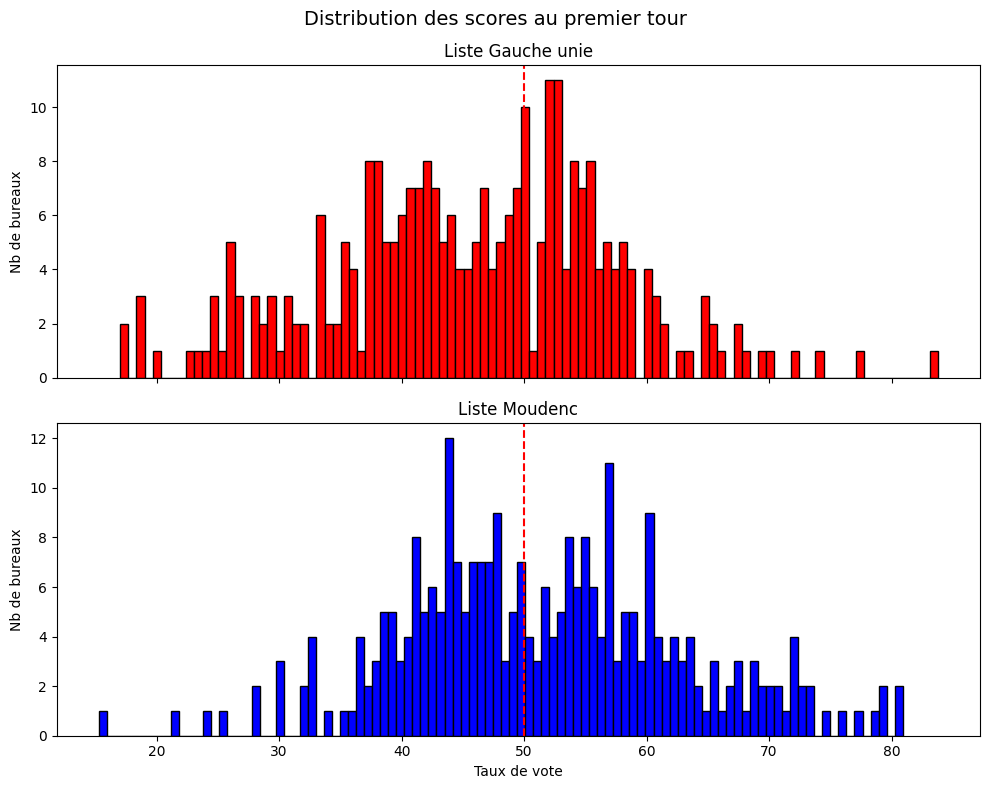

In [34]:
scores_gauche_unie = (deuxieme_tour['Piquemal'] / deuxieme_tour['votants']) *100
scores_Moudenc = (deuxieme_tour['Moudenc'] / deuxieme_tour['votants']) *100

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

axes[0].hist(scores_gauche_unie, bins=100, edgecolor='black', facecolor='red')
axes[0].set_title('Liste Gauche unie')
axes[0].set_ylabel('Nb de bureaux')

axes[1].hist(scores_Moudenc, bins=100, edgecolor='black', facecolor='blue')
axes[1].set_title('Liste Moudenc')
axes[1].set_ylabel('Nb de bureaux')

axes[1].set_xlabel('Taux de vote')

fig.suptitle('Distribution des scores au premier tour', fontsize=14)
for ax in axes:
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1.5)
    
plt.tight_layout()
plt.show()